# Initalization

In [5]:
%matplotlib inline

In [6]:
import os

import numpy as np
import warnings
warnings.filterwarnings('ignore', message='No contour levels were found')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['pdf.compression'] = 6
mpl.rcParams['pdf.use14corefonts'] = True
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

colors = ['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

import cmocean

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

import sys
sys.path.append('../analysis/')
# m6toolbox is a python package that has a function that helps visualize vertical sections
import m6toolbox

sys.path.insert(0, '../pittwolfe')
import pittwolfe as pw
from pittwolfe.util import sind, cosd

## Specify the experiment

In [24]:
# expdir = '../../flat/base'
# expdir = '../../flat/gm_0500'
expdir = '../../slope/base'

# Function definitions

In [8]:
def savefig(fig, name):
    fig.savefig(os.path.join(expdir, name + '.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(expdir, name + '.png'), bbox_inches='tight', dpi=150)

findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: DejaVu Sans


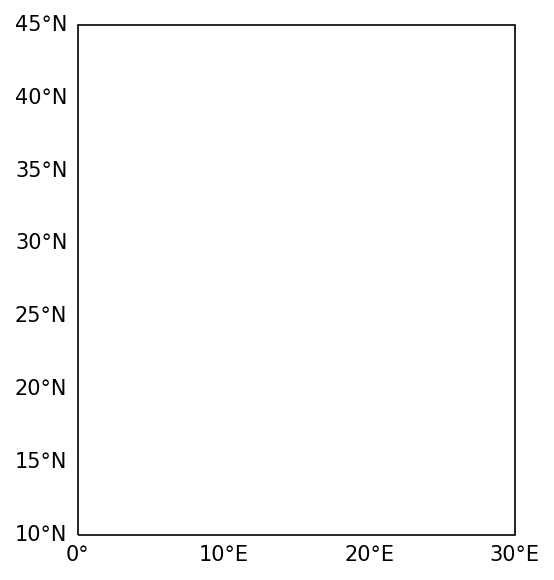

In [9]:
def setup_cartopy_plot(ax=None, bottom_labels=True, left_labels=True):
    data_projection = ccrs.PlateCarree()
    map_projection = ccrs.PlateCarree()
#     map_projection = ccrs.AlbersEqualArea(central_longitude=15, 
#                                           central_latitude=25,
#                                           standard_parallels=(20.0, 50.0))

    if ax is None:
        ax = plt.axes(projection=map_projection)

    ax.set_extent([-0.001, 30.001, 9.999, 45.0001], crs=ccrs.PlateCarree())
    gl = ax.gridlines(xlocs=np.arange(0, 31, 10), draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = bottom_labels
    gl.left_labels = left_labels
    gl.xlines = False
    gl.ylines = False

    vertices = [
        [ 0, 10],
        [30, 10],
        [30, 45],
        [ 0, 45],
        [ 0, 10]
    ]

    path = mpath.Path(vertices).interpolated(20)

#     ax.background_patch.set_facecolor('.5')
#     xlocs = np.arange(-90, 240, 30)
#     ylocs = np.arange(-75, 90, 15)
#     ax.gridlines(xlocs=xlocs, ylocs=ylocs, linewidth=.5)
#     ax.set_boundary(path, transform=data_projection)
    
    return ax

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
setup_cartopy_plot(ax)
savefig(fig, 'test')

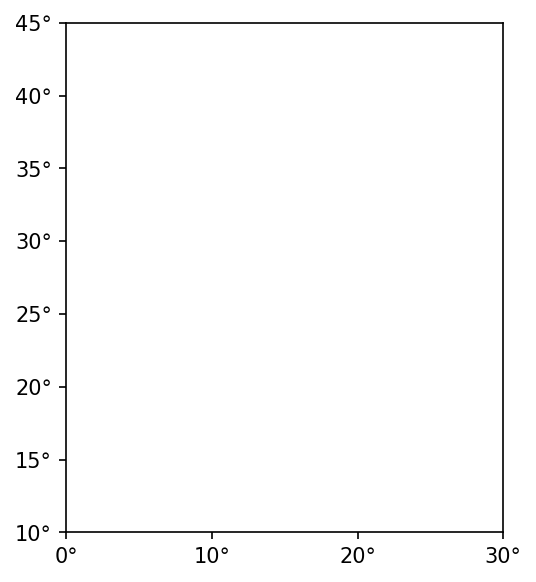

In [10]:
def setup_plan_plot(ax=None):
    if ax is None:
        ax = plt.axes()

    ax.set_xlim(0, 30)
    ax.set_ylim(10, 45)
    
    yticks = np.arange(10, 46, 5)
    latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
    ax.set_yticks(yticks)
    ax.set_yticklabels(latFormatter.format(yticks))
    
    xticks = np.arange(0, 31, 10)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))
    
    ax.set_aspect(1)
    
    return ax

fig, ax = plt.subplots()
setup_plan_plot(ax)
savefig(fig, 'test')

# Load datasets

## Constants

In [11]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [12]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [25]:
grid = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean_geometry.nc')).rename(coord_map_h)
ic = xr.open_dataset(os.path.join(expdir, 'OUTPUT/MOM_IC.nc')).squeeze().rename({**coord_map_h, **coord_map_v})

Nx = len(grid.xh)
Ny = len(grid.yh)

grid['zi'] = ic.zi
grid['zl'] = ic.zl

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid['maskH'] = grid.wet
grid['maskU'] = (['yh', 'xq'], np.ones((Ny, Nx+1)))
grid['maskU'][:,[0, -1]] = 0
grid['maskV'] = (['yq', 'xh'], np.ones((Ny+1, Nx)))
grid['maskV'][[0, -1],:] = 0

grid['maskZ'] = (['yq', 'xq'], np.ones((Ny+1, Nx+1)))
grid['maskZ'][[0, -1],:] = 0
grid['maskZ'][:,[0, -1]] = 0

grid

<xarray.Dataset>
Dimensions:  (yh: 81, xh: 60, yq: 82, xq: 61, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/27)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    βh       (yh) float64 2.252e-11 2.249e-11 2.245e-11 ... 1.632e-11 1.622e-11
    βq       (yq) float64 2.254e-11 2.251e-11 2.247e-11 ... 1.627e-11 1.617e-11
    maskH    (yh, xh) float64 ...
    maskU    (yh, xq) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    maskV    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    maskZ    (yq, xq) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    filename:  ./ocean_geometry.nc

In [26]:
grid_op = xgcm.Grid(grid, periodic=False, boundary='fill', fill_value=0, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, boundary='fill'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, boundary='fill'):
  * inner    zl
  * outer    zi

## Forcing

In [27]:
forcing = xr.open_dataset(os.path.join(expdir, 'INPUT/forcing.nc'))

# make sure the coordinates match exactly
forcing['xh'] = grid.xh 
forcing['xq'] = grid.xq[:-1]
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
    Time      timedelta64[ns] 00:00:00
Data variables:
    STRESS_X  (yh, xq) float64 ...
    STRESS_Y  (yq, xh) float64 ...

## Statistics

In [28]:
stats = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean.stats.nc'))
stats

<xarray.Dataset>
Dimensions:        (Layer: 2, Interface: 3, Time: 108001)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.036e+03
  * Interface      (Interface) float64 1.034e+03 1.036e+03 1.037e+03
  * Time           (Time) timedelta64[ns] 0 days ... -105504 days +00:25:26.2...
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [29]:
prog = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/ave_prog*.nc'), decode_times=False)
prog

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 3600, nv: 2, xh: 60, yq: 82, zi: 3)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 15.0 45.0 75.0 ... 1.079e+05 1.08e+05 1.08e+05
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * zi          (zi) float64 1.034e+03 1.036e+03 1.037e+03
Data variables:
    u           (time, zl, yh, xq) float32 dask.array<chunksize=(120, 2, 81, 61), meta=np.ndarray>
    v           (time, zl, yq, xh) float32 dask.array<chunksize=(120, 2, 82, 60), meta=np.ndarray>
    h           (time, zl, yh, xh) float64 dask.array<chunksize=(120, 2, 81, 60), meta=np.ndarray>
    e           (time, zi, yh, xh) float32 dask.array<chunksize=(120, 3, 81, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

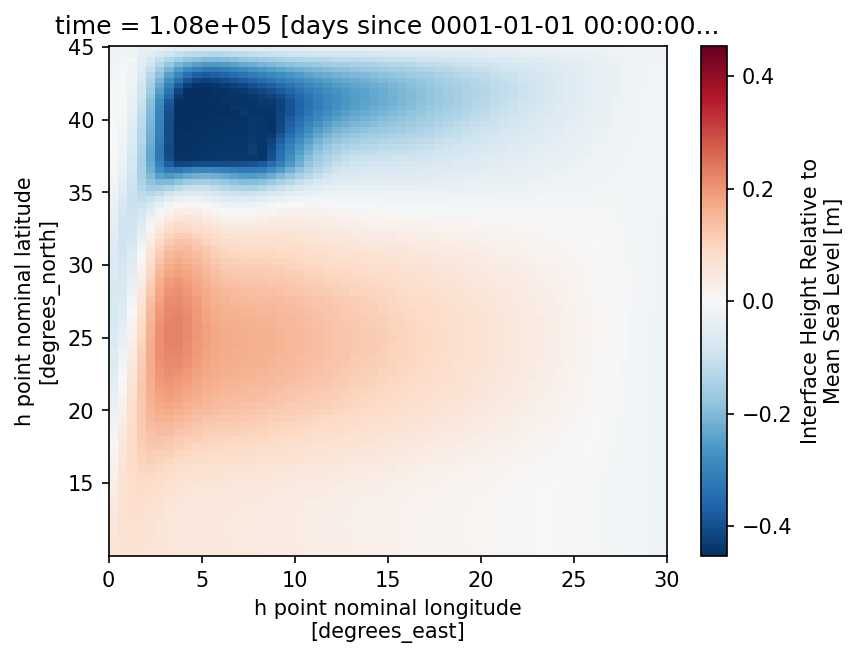

In [30]:
pc = (prog.e.isel(time=-1, zi=0)).plot()

## Continuity

In [31]:
cont = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/cont*.nc'), decode_times=False)
cont

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 3600, nv: 2, xh: 60, yq: 82)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 15.0 45.0 75.0 ... 1.079e+05 1.08e+05 1.08e+05
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(120, 2, 81, 61), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(120, 2, 82, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

# Calculations

## TWA quantities

### Thicknesses and velocities

In [32]:
h_at_u = grid_op.interp(prog.h, 'X').where(grid.maskU > 0)
h_at_v = grid_op.interp(prog.h, 'Y').where(grid.maskV > 0)
h_at_q = grid_op.interp(h_at_u.fillna(0), 'Y').where(grid.maskZ > 0)


# TWA velocities
uhat = cont.uh/h_at_u/grid.dyCuo
vhat = cont.vh/h_at_v/grid.dxCvo

In [33]:
twa = xr.Dataset({'h': prog.h, 'h_at_u': h_at_u, 'h_at_v': h_at_v, 'h_at_q': h_at_q,
                  'uhat': uhat, 'vhat': vhat})
twa

<xarray.Dataset>
Dimensions:  (yh: 81, zl: 2, time: 3600, xh: 60, xq: 61, yq: 82)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl       (zl) float64 1.035e+03 1.036e+03
  * time     (time) float64 15.0 45.0 75.0 105.0 ... 1.079e+05 1.08e+05 1.08e+05
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    h        (time, zl, yh, xh) float64 dask.array<chunksize=(120, 2, 81, 60), meta=np.ndarray>
    h_at_u   (time, zl, yh, xq) float64 dask.array<chunksize=(120, 2, 81, 1), meta=np.ndarray>
    h_at_v   (time, zl, yq, xh) float64 dask.array<chunksize=(120, 2, 1, 60), meta=np.ndarray>
    h_at_q   (time, zl, yq, xq) float64 dask.array<chunksize=(120, 2, 1, 1), meta=np.ndarray>
    uhat     (time, zl, yh, xq) float64 dask.array<chunksize=(120, 2, 81, 1), meta=np.ndarray>
    vhat     (time, zl, yq, xh) float64 dask.array<chunksize=(120, 2, 1, 60), meta=np.ndarray>

### Vorticity

The "vorticity" field appearing in the TWA is 

$$
\zeta^\sharp = \frac{1}{\Delta x \Delta y}\left[\delta_i(\Delta y \hat{v})  - \delta_j(\Delta x\hat{u})\right],
$$

where the hats are designate thickness-weighted quantities. This is not the TWA of the vorticity, hence the sharp sign.

The PV is

$$
\Pi^\sharp = \frac{\zeta^\sharp + f}{\bar{h}}.
$$

In [57]:
h_at_q.isel(time=-1, zl=1).sel(yq=25, method='nearest').values

array([           nan, 1.00000000e-10, 1.00013742e-10, 1.85244931e+02,
       9.27331256e+02, 2.04181533e+03, 2.88227633e+03, 3.24063947e+03,
       3.33157408e+03, 3.35492115e+03, 3.36961292e+03, 3.38130509e+03,
       3.38933846e+03, 3.39409666e+03, 3.39674245e+03, 3.39852190e+03,
       3.40035780e+03, 3.40273338e+03, 3.40576037e+03, 3.40932141e+03,
       3.41321043e+03, 3.41723238e+03, 3.42125353e+03, 3.42521097e+03,
       3.42909750e+03, 3.43293754e+03, 3.43676519e+03, 3.44060969e+03,
       3.44448906e+03, 3.44841004e+03, 3.45237137e+03, 3.45636801e+03,
       3.46039460e+03, 3.46444752e+03, 3.46852558e+03, 3.47262968e+03,
       3.47676208e+03, 3.48092552e+03, 3.48512260e+03, 3.48935539e+03,
       3.49362538e+03, 3.49793356e+03, 3.50228058e+03, 3.50666698e+03,
       3.51109332e+03, 3.51556022e+03, 3.52006843e+03, 3.52461870e+03,
       3.52921163e+03, 3.53384692e+03, 3.53850106e+03, 3.54252183e+03,
       3.53660481e+03, 3.45579504e+03, 3.09278796e+03, 2.22620693e+03,
      

In [58]:
twa['zeta'] = (grid_op.diff(twa.vhat*grid.dyCv, 'X') - grid_op.diff(twa.uhat*grid.dxCu, 'Y'))/(grid.dxBu*grid.dyBu)
twa['Pi'] = ((twa.zeta + grid.fq)/twa.h_at_q).where(twa.h_at_q > 1)

# Plot

## Convergence

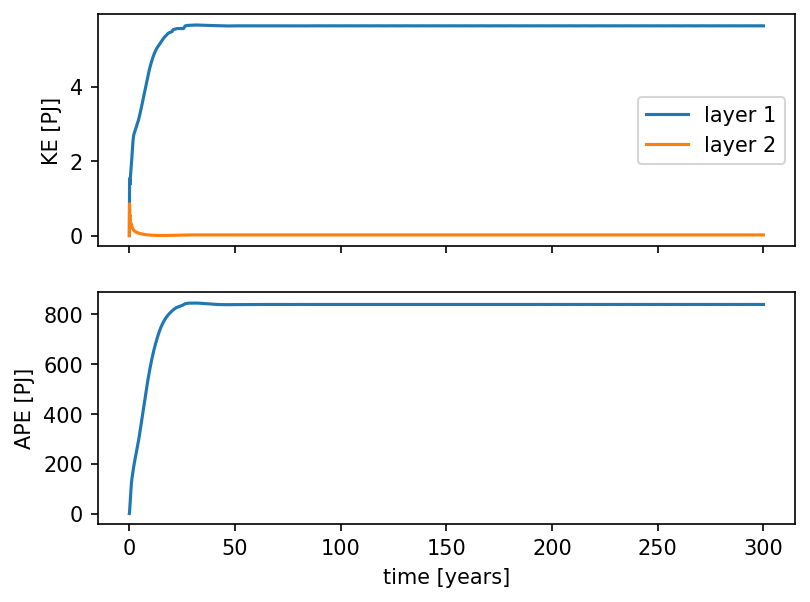

In [35]:
years = np.arange(len(stats.Time))/360

fig, axs = plt.subplots(nrows=2, sharex=True)

ax = axs[0]
ax.plot(years, stats.KE.isel(Layer=0)/1e15, label='layer 1')
ax.plot(years, stats.KE.isel(Layer=1)/1e15, label='layer 2')
ax.legend()
ax.set_ylabel('KE [PJ]')

ax = axs[1]
ax.plot(years, stats.APE.isel(Interface=1)/1e15)
ax.set_ylabel('APE [PJ]')
ax.set_xlabel('time [years]')

savefig(fig, 'energy')

## SSH

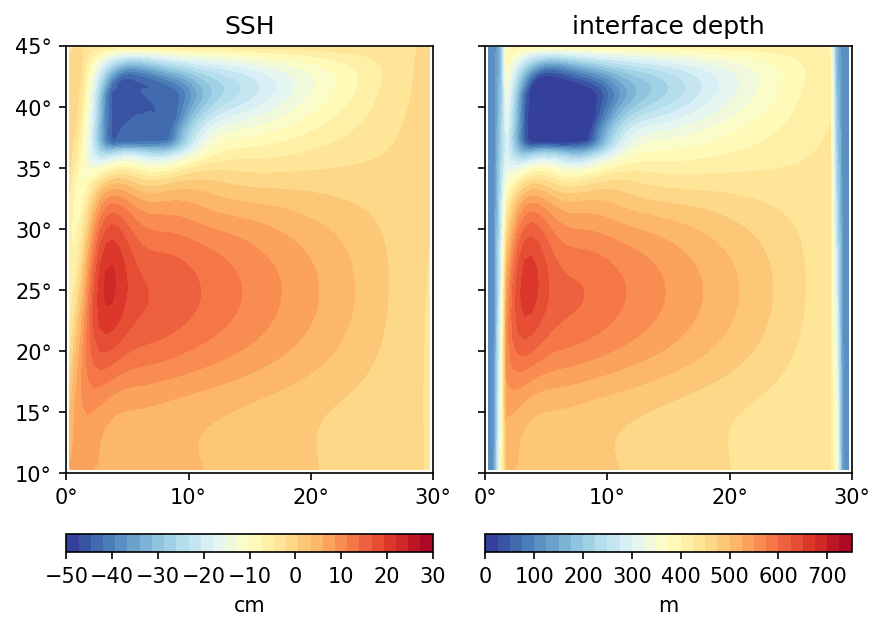

In [36]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)


ax = axs[0]
setup_plan_plot(ax)
fld = 100*prog.e.isel(time=-1, zi=0)
vmax =  30
vmin = -50
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax)
ax.set_aspect(1)
ax.set_title('SSH')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=np.arange(-50, 31, 10), pad=.1, label='cm')

ax = axs[1]
setup_plan_plot(ax)
fld = -prog.e.isel(time=-1, zi=1)
# vmax = float(fld.max())
# vmin = float(fld.min())
vmax = 750
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax)
ax.set_aspect(1)
ax.set_title('interface depth')
fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='m')

fig.tight_layout()
savefig(fig, 'ssh')

## Streamfunctions

### Barotropic

In [37]:
psiB = grid_op.cumsum(cont.vh.sum(dim='zl'), axis='X', to='outer', boundary='fill')/1e6

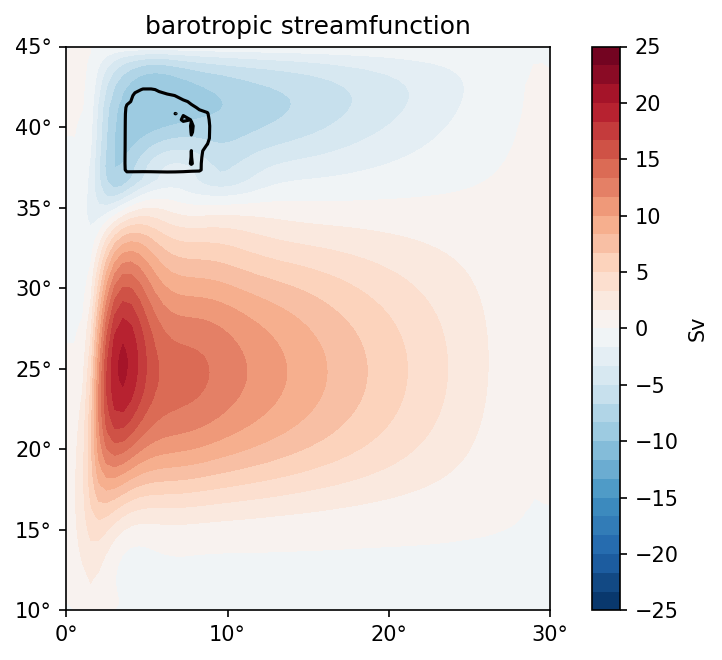

In [38]:
fld = psiB.isel(time=-1)

vmax = 25
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

fig, ax = plt.subplots()
setup_plan_plot(ax)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax.contour(grid.xh, grid.yh, prog.h.isel(zl=0, time=-1), levels=[10], colors='k')
ax.set_aspect(1)
fig.colorbar(cs, ax=ax, ticks=np.arange(-25, 26, 5), label='Sv')
ax.set_title('barotropic streamfunction')

fig.tight_layout()
savefig(fig, 'barotropic_streamfunction')

### Layerwise

In [39]:
psi = grid_op.cumsum(cont.vh.isel(time=-1), axis='X', to='outer', boundary='fill')/1e6

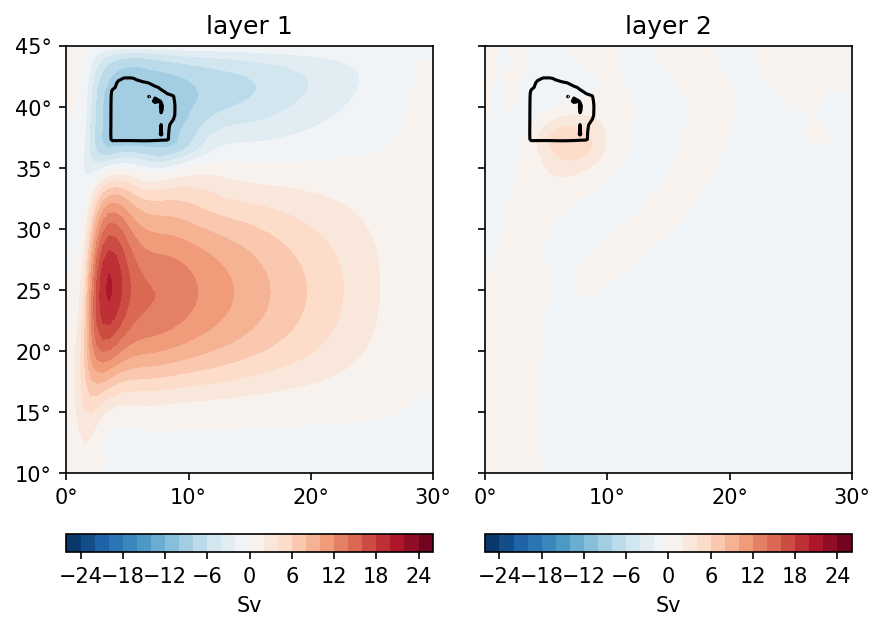

In [40]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

ax = axs[0]
setup_plan_plot(ax)
vmax = 26
vmin = -vmax
levels = np.arange(vmin, vmax+1, 2)
cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax.contour(grid.xh, grid.yh, prog.h.isel(zl=0, time=-1), levels=[10], colors='k')
fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1)
ax.set_title('layer 1')

ax = axs[1]
setup_plan_plot(ax)
cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax.contour(grid.xh, grid.yh, prog.h.isel(zl=0, time=-1), levels=[10], colors='k')
fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1)
ax.set_title('layer 2')

fig.tight_layout()
savefig(fig, 'layer_streamfunctions')

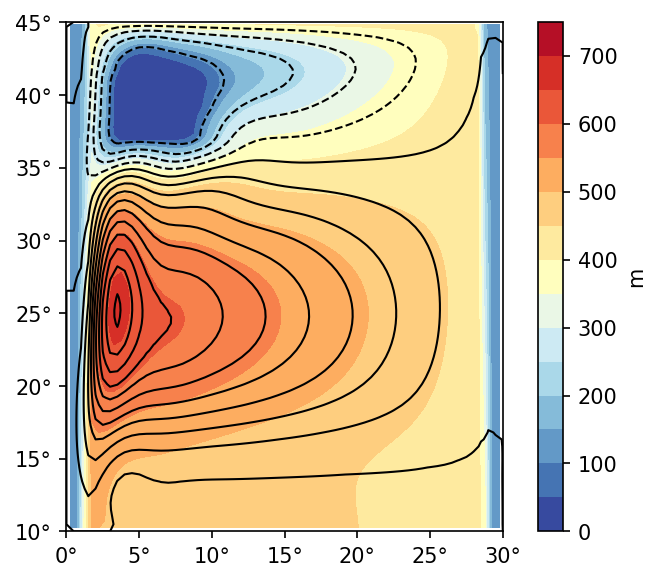

In [41]:
vmin = 0
vmax = 750
levels = np.arange(vmin, vmax+1, 50)

fig, ax = plt.subplots()

h = prog.h.isel(zl=0, time=-1)
cs = ax.contourf(h.xh, h.yh, h, levels=levels, vmin=vmin, vmax=vmax)
ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.contour(lon, lat, psi2, levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.plot(np.rad2deg(λo), lat, ls='-', color='tab:gray', lw=2)

fig.colorbar(cs, label='m')

yticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_yticks(yticks)
ax.set_yticklabels(latFormatter.format(yticks))

xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))

ax.set_aspect(1)

savefig(fig, 'thickness_psi_mom')

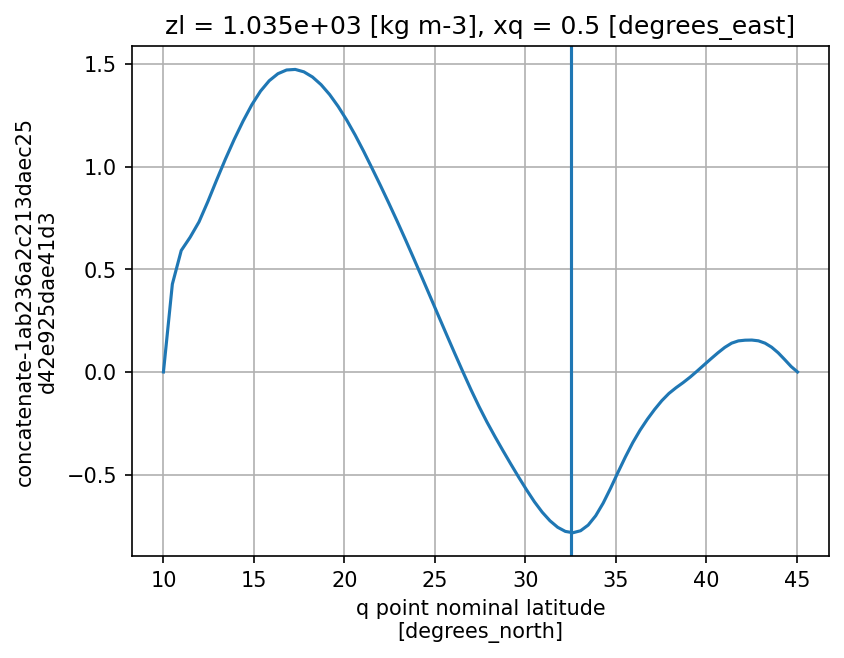

In [42]:
psi.isel(zl=0,xq=1).plot()
plt.grid()
plt.axvline(32.5)

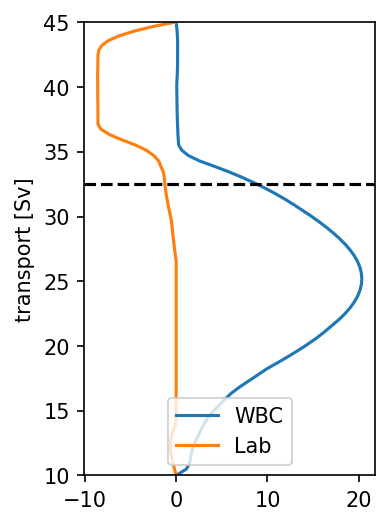

In [43]:
T_wbc = psi.isel(zl=0).max(dim='xq')
T_lab = psi.isel(zl=0).min(dim='xq')

fig, ax = plt.subplots(figsize=(2.5,4))

ax.plot(T_wbc, T_wbc.yq, label='WBC')
ax.plot(T_lab, T_wbc.yq, label='Lab')
ax.set_ylabel('transport [Sv]')

ax.set_ylim([10, 45])
ax.legend(loc='lower center')
ax.axhline(32.5, color='k', ls='--')

savefig(fig, 'outcrop_transports_mom')

## Velocities

### Layerwise

In [44]:
u = 100*grid_op.interp(twa.uhat.isel(time=-1), 'X')
v = 100*grid_op.interp(twa.vhat.isel(time=-1), 'Y')

speed = np.sqrt(u**2 + v**2)

In [45]:
speed.isel(zl=0).max().values

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


array(40.42304158)

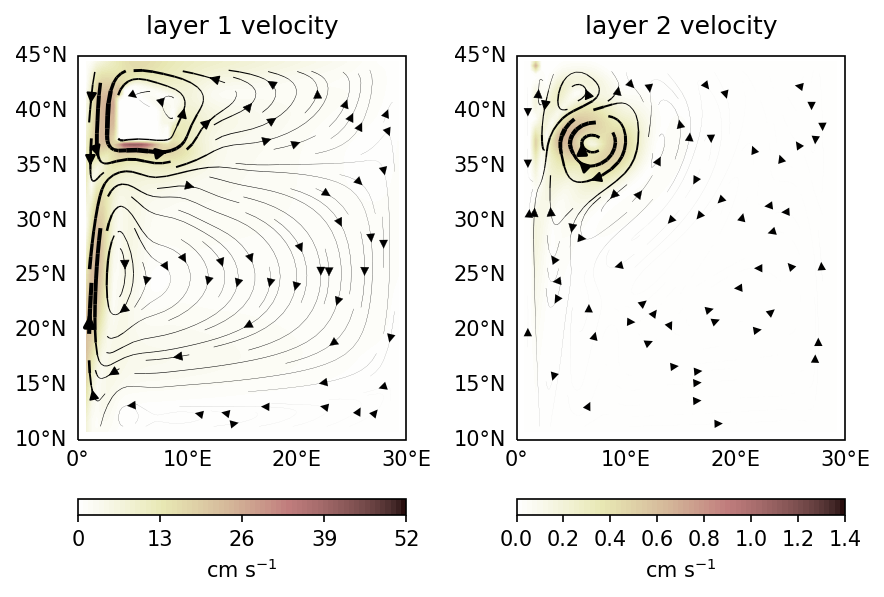

In [46]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

vm = [52, 1.4]
cticks = [np.arange(0, 53, 13), np.arange(0, 1.5, .2)]
for zl in range(2):
    ax = axs[zl]
    setup_cartopy_plot(ax)
    vmax = vm[zl]
    vmin = 0
    levels = np.linspace(vmin, vmax, 64)

    lw = (5*speed.isel(zl=zl) / vmax).values

    cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
                          vmin=vmin, vmax=vmax, cmap='pink_r',
                          transform=data_projection)
    sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
                  transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
    fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$', pad=.1)

axs[0].set_title('layer 1 velocity')
axs[1].set_title('layer 2 velocity')
    
fig.tight_layout()
savefig(fig, 'velocities')

### Barotropic

In [47]:
U = 100*grid_op.interp(cont.uh.isel(time=-1).sum(dim='zl')/grid.dyCu, 'X')/grid.D
V = 100*grid_op.interp(cont.vh.isel(time=-1).sum(dim='zl')/grid.dxCv, 'Y')/grid.D

speed = np.sqrt(U**2 + V**2)

In [48]:
speed.max().values

array(27.20337039)

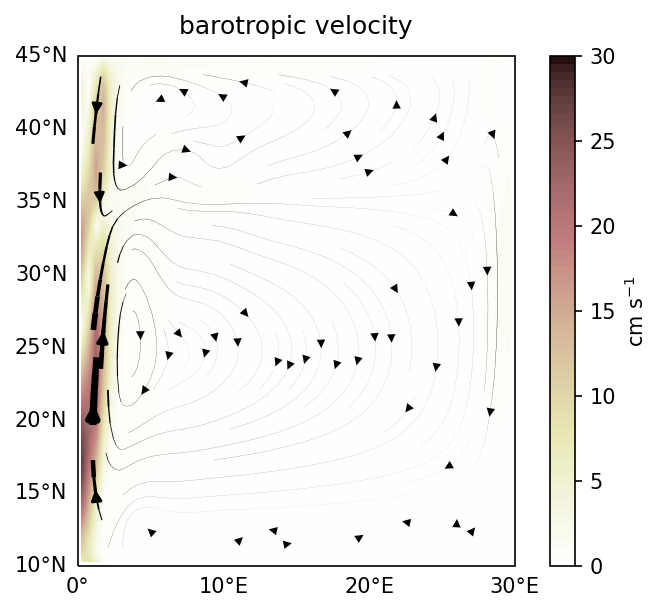

In [62]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

setup_cartopy_plot(ax)
vmax = 30
vmin = 0
levels = np.linspace(vmin, vmax, 64)

lw = (5*speed / vmax).values

cs = ax.contourf(grid.xh.values, grid.yh.values, speed.values, levels, 
                      vmin=vmin, vmax=vmax, cmap='pink_r',
                      transform=data_projection)
sp = ax.streamplot(grid.xh.values, grid.yh.values, U.values, V.values,
              transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
fig.colorbar(cs, ax=ax, ticks=np.arange(0, 35, 5), label=r'cm s$^{-1}$')
ax.set_title('barotropic velocity')

savefig(fig, 'barotropic_velocities')

## PV

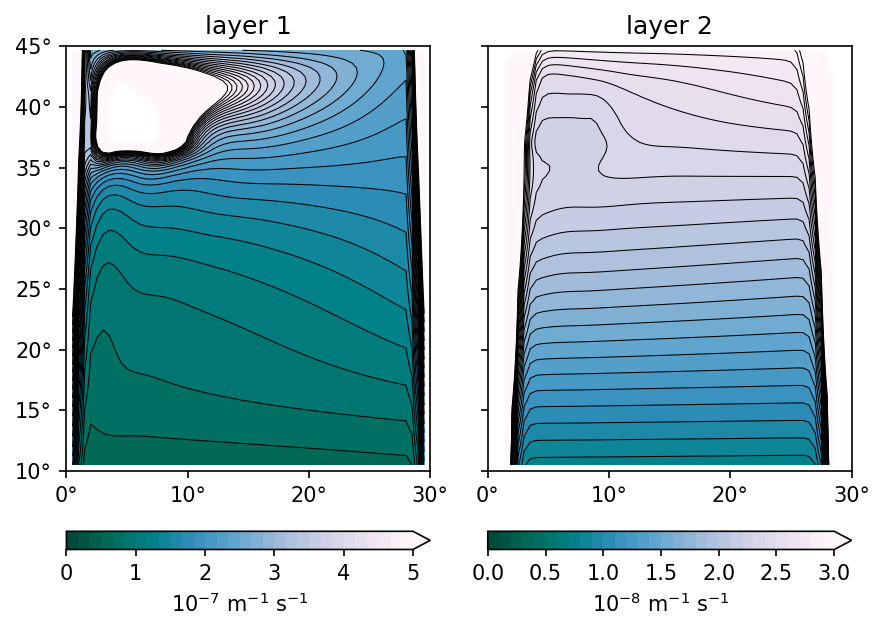

In [69]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

fld = 1e7*twa.Pi.isel(time=-1)

ax = axs[0]
setup_plan_plot(ax)
vmax = 5
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
ax.contour(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, colors='k', linewidths=.5)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 6, 1))
ax.set_title('layer 1')

ax = axs[1]
setup_plan_plot(ax)
vmax = 3
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
ax.contour(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, colors='k', linewidths=.5)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-8}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 3.5, .5))
ax.set_title('layer 2')

fig.tight_layout()
savefig(fig, 'layer_PV')

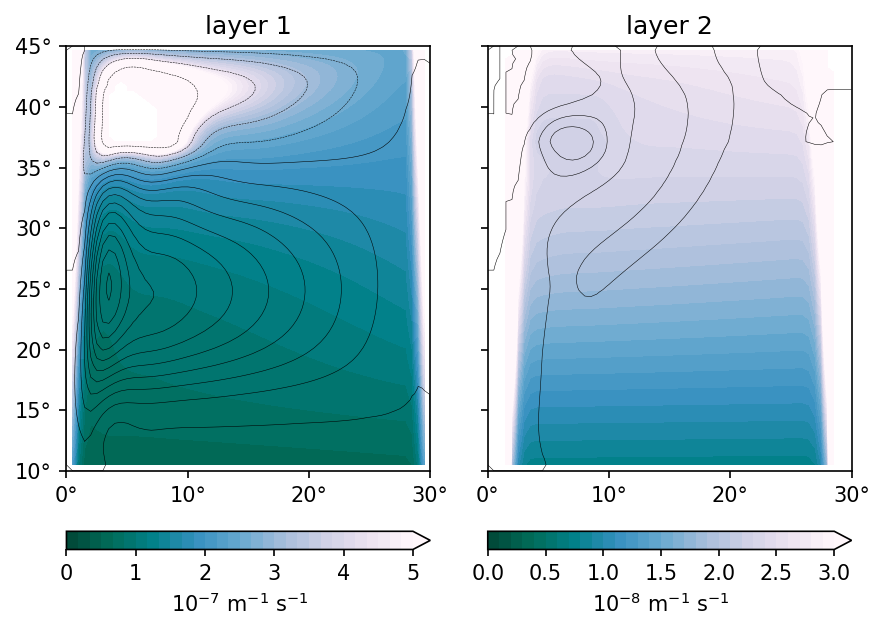

In [68]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

fld = 1e7*twa.Pi.isel(time=-1)

ax = axs[0]
setup_plan_plot(ax)
vmax = 5
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 6, 1))
ax.set_title('layer 1')

ax = axs[1]
setup_plan_plot(ax)
vmax = 3
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-8}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 3.5, .5))
ax.set_title('layer 2')

fig.tight_layout()
savefig(fig, 'layer_steamfunction_PV')

## WBCs

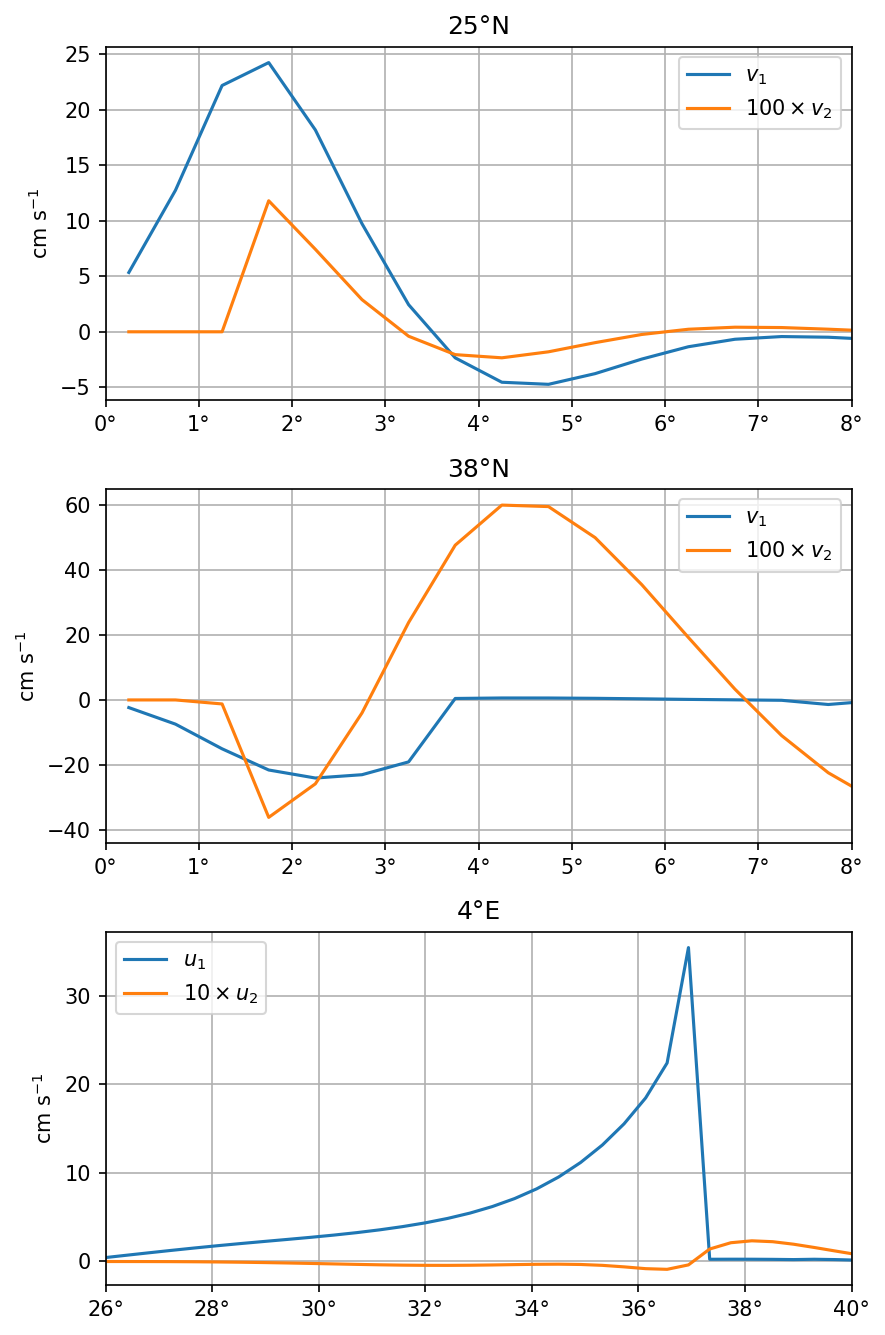

In [53]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

ax = axs[0]
fld = twa.vhat.isel(time=-1, zl=0).sel(yq=25, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, 100*fld, label='$v_1$')
fld = 100*twa.vhat.isel(time=-1, zl=1).sel(yq=25, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, 100*fld, label=r'$100\times v_2$')
ax.grid()
ax.set_xlim([0, 8])
ax.legend()
ax.set_title('25\N{DEGREE SIGN}N')

ax = axs[1]
fld = twa.vhat.isel(time=-1, zl=0).sel(yq=38, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, 100*fld, label='$v_1$')
fld = 100*twa.vhat.isel(time=-1, zl=1).sel(yq=38, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, 100*fld, label=r'$100\times v_2$')
ax.grid()
ax.set_xlim([0, 8])
ax.legend()
ax.set_title('38\N{DEGREE SIGN}N')

for ax in axs[:-1]:
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))


ax = axs[2]
fld = twa.uhat.isel(time=-1, zl=0).sel(xq=4, method='nearest').sel(yh=slice(25, 41))
ax.plot(fld.yh, 100*fld, label='$u_1$')
fld = 10*twa.uhat.isel(time=-1, zl=1).sel(xq=4, method='nearest').sel(yh=slice(25, 41))
ax.plot(fld.yh, 100*fld, label=r'$10\times u_2$')
ax.grid()
ax.set_xlim([26, 40])
ax.legend()
ax.set_title('4\N{DEGREE SIGN}E')
xticks = np.arange(26, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

for ax in axs:
    ax.set_ylabel('cm s$^{-1}$')

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_velocities')

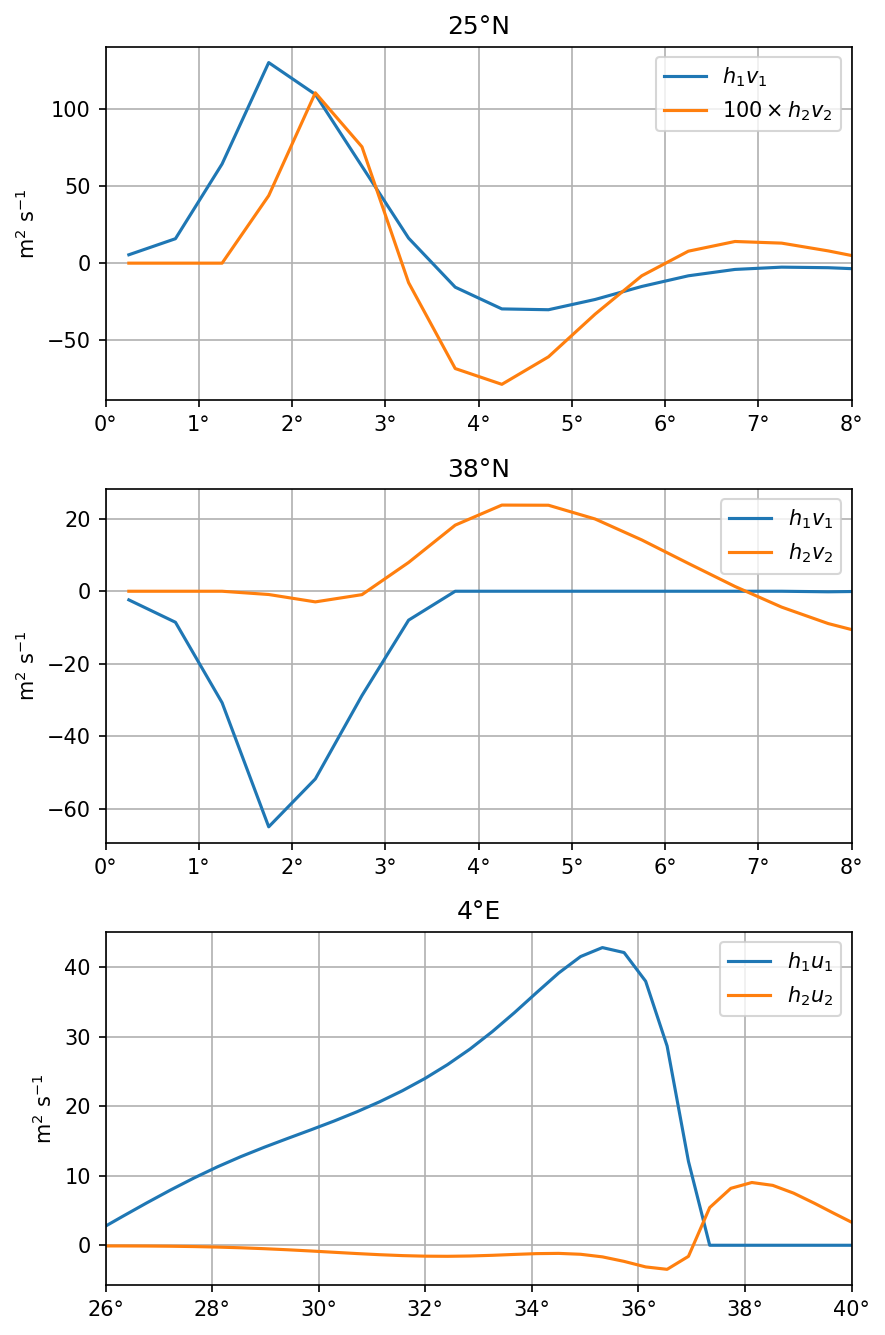

In [54]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

ax = axs[0]
fld = (twa.h_at_v*twa.vhat).isel(time=-1, zl=0).sel(yq=25, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, fld, label='$h_1 v_1$')
fld = (twa.h_at_v*twa.vhat).isel(time=-1, zl=1).sel(yq=25, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, 100*fld, label=r'$100\times h_2 v_2$')
ax.grid()
ax.set_xlim([0, 8])
ax.legend()
ax.set_title('25\N{DEGREE SIGN}N')

ax = axs[1]
fld = (twa.h_at_v*twa.vhat).isel(time=-1, zl=0).sel(yq=38, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, fld, label='$h_1 v_1$')
fld = (twa.h_at_v*twa.vhat).isel(time=-1, zl=1).sel(yq=38, method='nearest').sel(xh=slice(0, 9))
ax.plot(fld.xh, fld, label=r'$h_2 v_2$')
ax.grid()
ax.set_xlim([0, 8])
ax.legend()
ax.set_title('38\N{DEGREE SIGN}N')

for ax in axs[:-1]:
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))


ax = axs[2]
fld = (twa.h_at_u*twa.uhat).isel(time=-1, zl=0).sel(xq=4, method='nearest').sel(yh=slice(25, 41))
ax.plot(fld.yh, fld, label='$h_1 u_1$')
fld = (twa.h_at_u*twa.uhat).isel(time=-1, zl=1).sel(xq=4, method='nearest').sel(yh=slice(25, 41))
ax.plot(fld.yh, fld, label=r'$h_2 u_2$')
ax.grid()
ax.set_xlim([26, 40])
ax.legend()
ax.set_title('4\N{DEGREE SIGN}E')
xticks = np.arange(26, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

for ax in axs:
    ax.set_ylabel('m$^2$ s$^{-1}$')

fig.subplots_adjust(hspace=.3)
fig.tight_layout()

savefig(fig, 'wbc_transports')

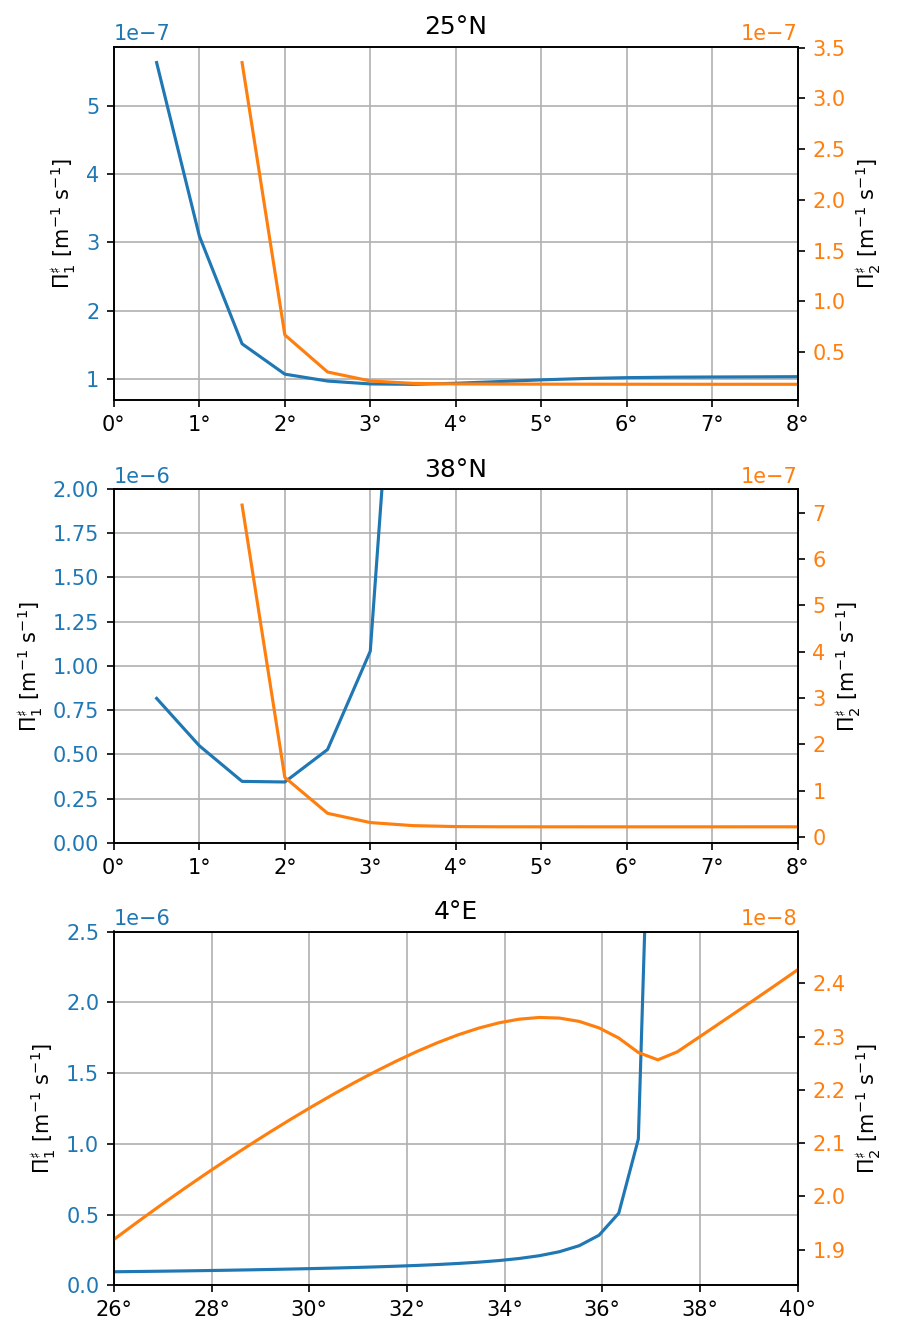

In [60]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

ax = axs[0]
fld = twa.Pi.isel(time=-1).sel(yq=25, method='nearest').sel(xq=slice(0, 9))
ax.plot(fld.xq, fld.isel(zl=0), color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0])
ax.set_ylabel(r'$\Pi^\sharp_1$ [m$^{-1}$ s$^{-1}$]')
ax2 = ax.twinx()
ax2.plot(fld.xq, fld.isel(zl=1), color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1])
ax2.set_ylabel(r'$\Pi^\sharp_2$ [m$^{-1}$ s$^{-1}$]')
ax.set_xlim([0, 8])
ax.grid()
ax.set_title('25\N{DEGREE SIGN}N')

ax = axs[1]
fld = twa.Pi.isel(time=-1).sel(yq=38, method='nearest').sel(xq=slice(0, 9))
ax.plot(fld.xq, fld.isel(zl=0), color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0])
ax.set_ylabel(r'$\Pi^\sharp_1$ [m$^{-1}$ s$^{-1}$]')
ax.set_ylim(0, 2e-6)
ax2 = ax.twinx()
ax2.plot(fld.xq, fld.isel(zl=1), color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1])
ax2.set_ylabel(r'$\Pi^\sharp_2$ [m$^{-1}$ s$^{-1}$]')
ax.set_xlim([0, 8])
ax.grid()
ax.set_title('38\N{DEGREE SIGN}N')

for ax in axs[:-1]:
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))


ax = axs[2]
fld = twa.Pi.isel(time=-1).sel(xq=4, method='nearest').sel(yq=slice(25, 41))
ax.plot(fld.yq, fld.isel(zl=0), color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0])
ax.set_ylabel(r'$\Pi^\sharp_1$ [m$^{-1}$ s$^{-1}$]')
ax.set_ylim(0, 2.5e-6)
ax2 = ax.twinx()
ax2.plot(fld.yq, fld.isel(zl=1), color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1])
ax2.set_ylabel(r'$\Pi^\sharp_2$ [m$^{-1}$ s$^{-1}$]')
ax.set_xlim([26, 40])
ax.grid()
ax.set_title('4\N{DEGREE SIGN}E')

xticks = np.arange(26, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_PV')

## Meridional Sections

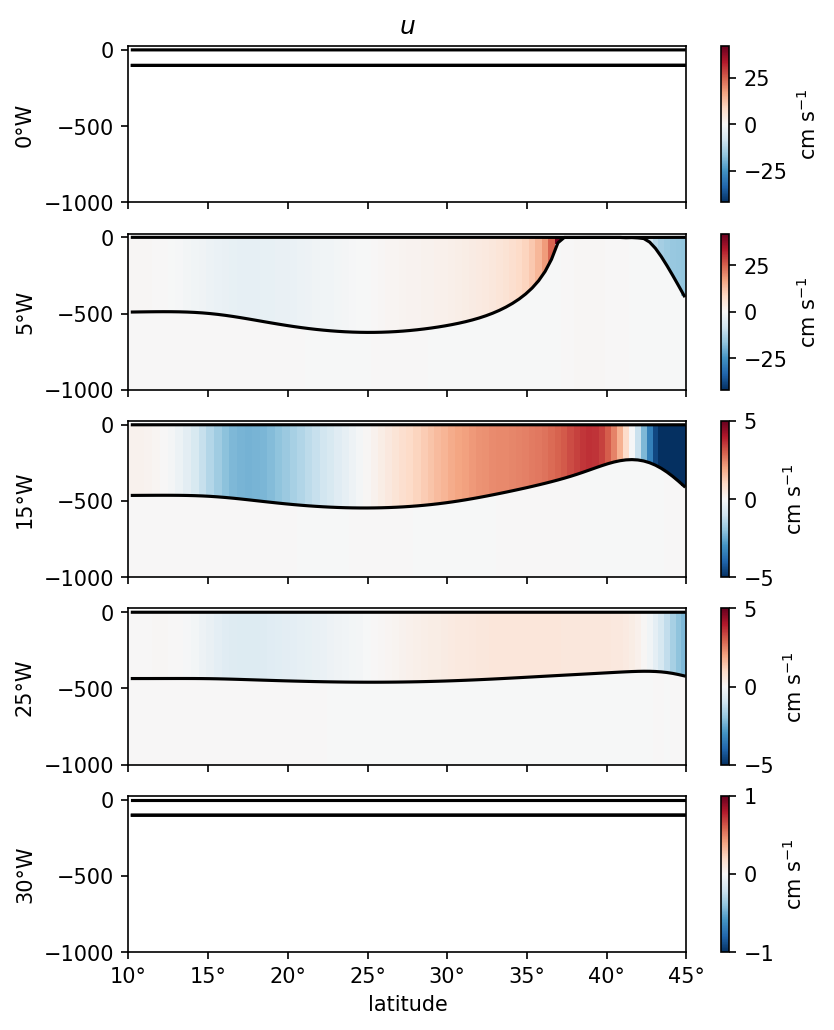

In [70]:
xlocs = [0, 5, 15, 25, 30]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

e = prog.e.isel(time=-1)
u = 100*grid_op.interp(twa.uhat.isel(time=-1), 'X')
vms = [42, 42, 5, 5, 1, 1]
for xloc, ax, vmax in zip(xlocs, axs, vms):
    for zi in range(3):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        u.sel(xh=xloc, method='nearest').values, representation='plm')
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:d}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])
axs[-1].set_xlabel('latitude')
axs[0].set_title('$u$')
xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

savefig(fig, 'meridional_u')

## Zonal Sections

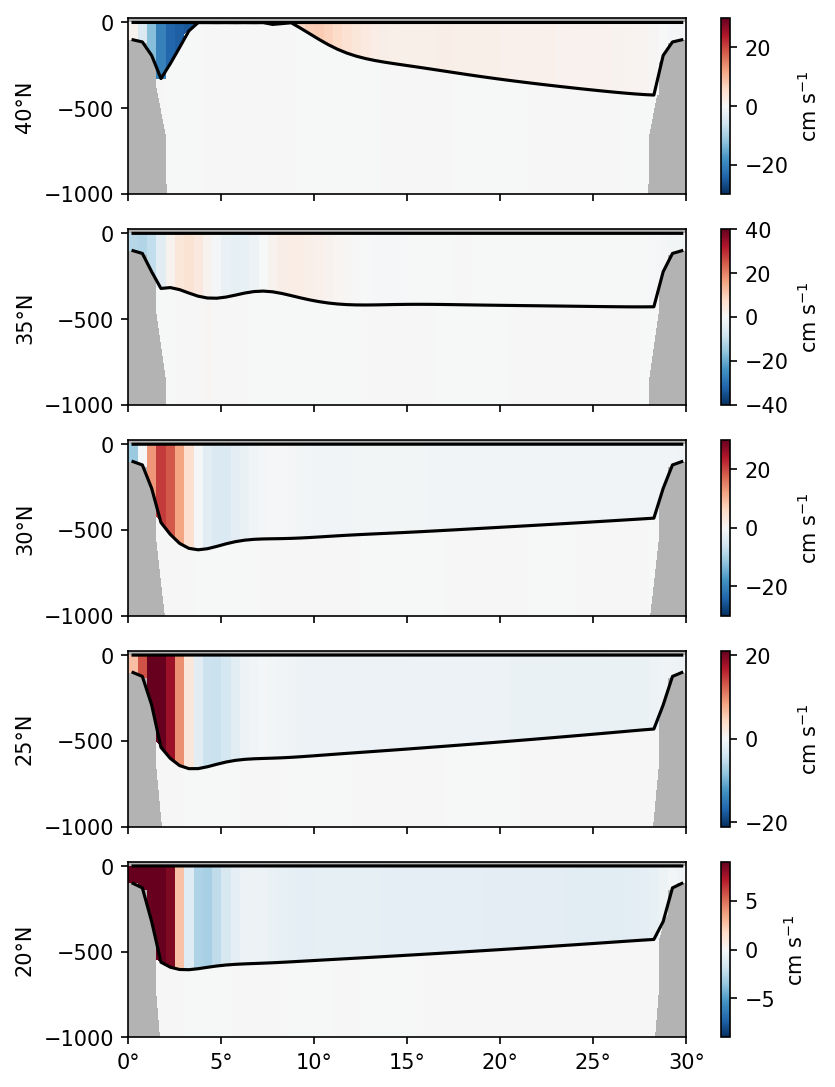

In [71]:
ylocs = [40, 35, 30, 25, 20]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,9))

e = prog.e.isel(time=-1)
v = 100*grid_op.interp(twa.vhat.isel(time=-1), 'Y')
vms = [30, 40, 30, 21, 9]
for yloc, ax, vmax in zip(ylocs, axs, vms):
    ax.set_facecolor('.7')
    for zi in range(2):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        v.sel(yh=yloc, method='nearest').values, representation='plm')
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:d}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])
xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))

savefig(fig, 'zonal_v')

# Close everything

In [72]:
grid.close()
ic.close()
forcing.close()
stats.close()
prog.close()
cont.close()